<a href="https://colab.research.google.com/github/MakwBansari/EduNetGTU/blob/main/day7_13_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 1- K-Means Clustering Workflow**

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [6]:
from google.colab import files

uploaded = files.upload()

Saving complete_renewable_energy_dataset.csv to complete_renewable_energy_dataset.csv


In [7]:
df = pd.read_csv("complete_renewable_energy_dataset.csv")

print(df.head())
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

     Country  Year Energy Type  Production (GWh)  Installed Capacity (MW)  \
0        USA  2011       Solar      85404.690027              5549.794323   
1  Australia  2008  Geothermal      22205.069382             43211.593798   
2     Canada  2013     Biomass      94102.732038              6139.117212   
3      Japan  2010     Biomass      88771.932910             40323.639260   
4      China  2018       Solar      93288.408581             30755.403056   

   Investments (USD)  Population           GDP  Energy Consumption  \
0       5.604125e+09  1064007213  1.775278e+14       369654.644184   
1       6.361886e+08  1033255852  6.435372e+13       771781.636293   
2       6.158680e+09    14895124  1.567926e+14       342707.152899   
3       8.526116e+09  1448827283  1.350464e+14       498839.574253   
4       5.086237e+09  1499494307  8.677956e+13       819064.362785   

   Energy Exports  ...  Economic Freedom Index  Ease of Doing Business  \
0    93087.198199  ...               49.21

## **Handle Missing Values**

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## **Dataset Analysis (Seaborn)**

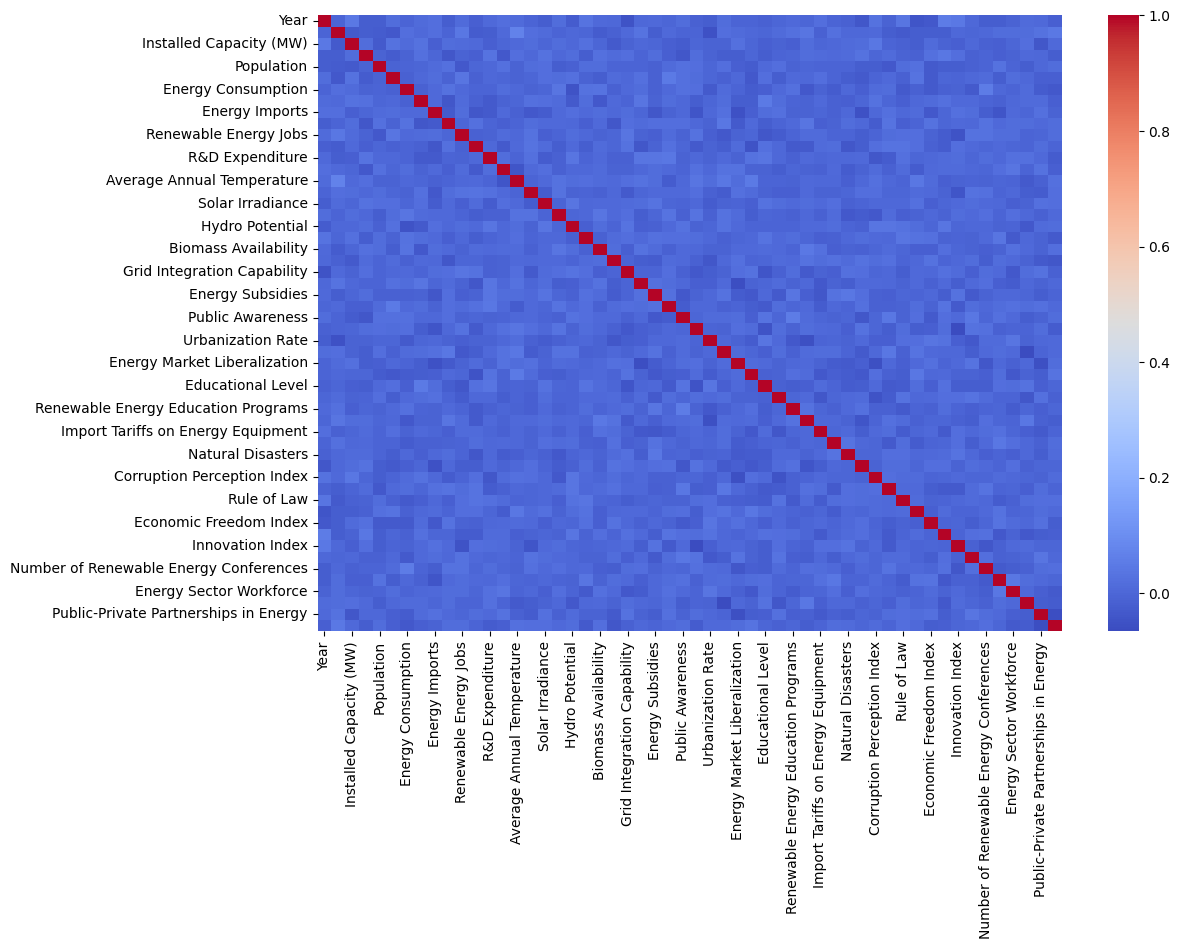

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap="coolwarm")

plt.show()

### **Histogram**

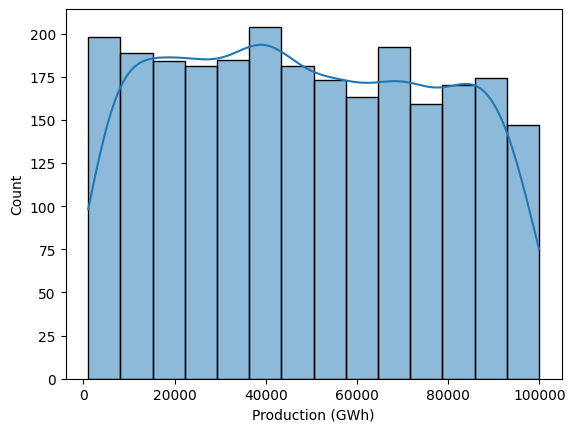

In [10]:
sns.histplot(df["Production (GWh)"], kde=True)

plt.show()

### **Boxplot**

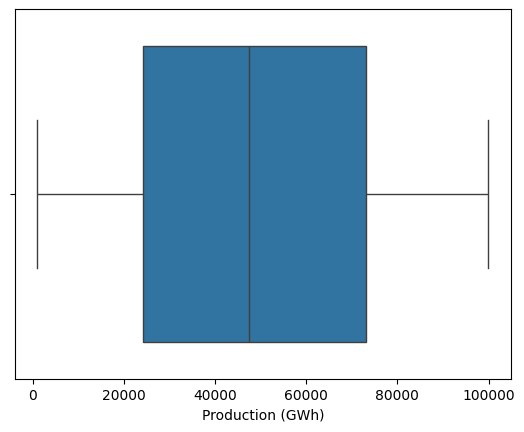

In [11]:
sns.boxplot(x=df["Production (GWh)"])

plt.show()

### **Scatter Plot**

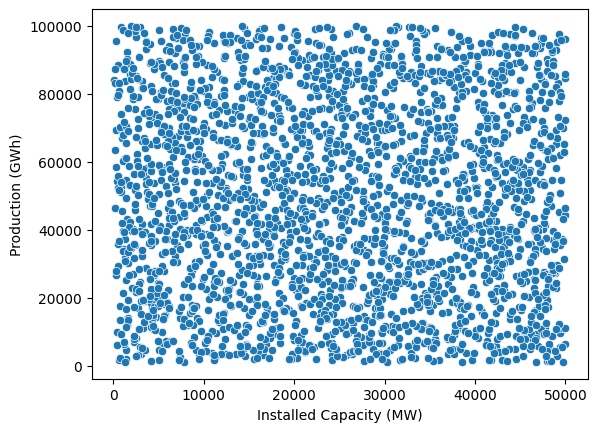

In [12]:
sns.scatterplot(
    data=df,
    x="Installed Capacity (MW)",
    y="Production (GWh)"
)

plt.show()

## **Select Features**

In [13]:
X = df[[
    "Production (GWh)",
    "Installed Capacity (MW)"
]]

## **Scaling**

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# **Elbow Method**

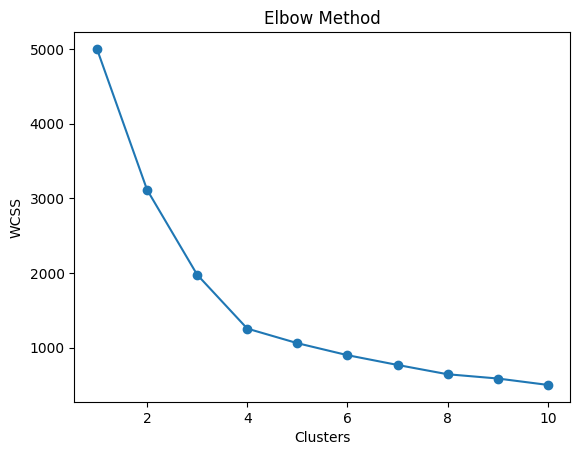

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# **Apply K-Means**

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

## **Cluster Visualization**

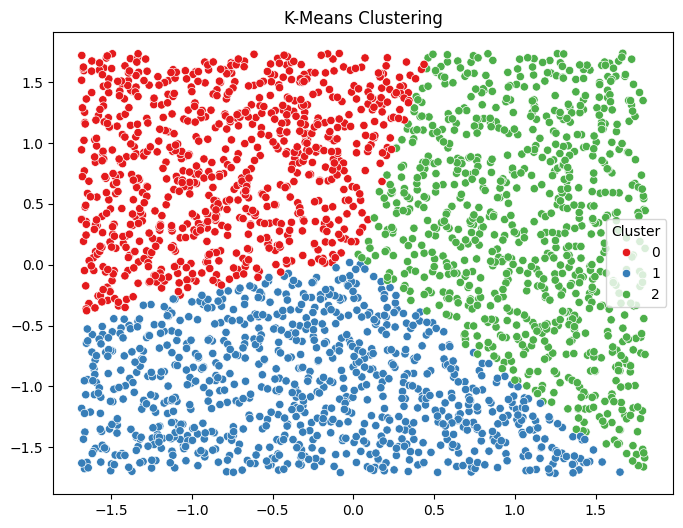

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("K-Means Clustering")

plt.show()

## **Evaluation**

In [18]:
score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.3775537866603857


# **Dataset Analysis**

- This dataset contains renewable energy information for different countries.

- The dataset includes production, installed capacity, investment, GDP, energy consumption, and several environmental indicators.

- The objective is to group similar observations using K-Means Clustering.

- Only numerical columns were selected because K-Means works on numerical data.

- Missing values were replaced using the mean for numerical columns and mode for categorical columns.

- The selected features were standardized using StandardScaler to ensure all features contribute equally during distance calculation.

- The Elbow Method was used to determine the optimal number of clusters.

- The Silhouette Score was used to evaluate the quality of clustering.

# **Insights**

- Similar renewable energy records were grouped into different clusters.
- StandardScaler improved clustering by bringing all numerical features to the same scale.
- The Elbow Method suggested the optimal number of clusters.
- The Silhouette Score indicates how well-separated the clusters are.
- Countries with similar renewable energy production and installed capacity were grouped together.
- K-Means helps identify hidden patterns in renewable energy data and supports sustainability analysis.